In [43]:
import pandas as pd
import numpy as np
# ignore scorecardpy compatability warnings
import warnings

import pandas as pd, numpy as np
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
from sklearn import linear_model, metrics
import scorecardpy as sc
import pprint
new_merged_df = pd.read_csv('clean_data/final_merged_data.csv')

In [45]:
new_merged_df.shape

(20104, 157)

In [2]:
#shinus columns
iteration1df = new_merged_df.copy()
iteration1df = iteration1df.drop(columns=['SK_ID_CURR'], axis = 1)
iteration1df = iteration1df.drop(columns=['CODE_GENDER'])
iteration1df = iteration1df.drop(columns=['FLAG_OWN_REALTY'])

In [3]:
#jewels columns
iteration1df = iteration1df.drop(columns=['APARTMENTS_AVG'])
iteration1df = iteration1df.drop(columns=['BASEMENTAREA_AVG'])
iteration1df = iteration1df.drop(columns=['YEARS_BEGINEXPLUATATION_AVG'])
iteration1df = iteration1df.drop(columns=['YEARS_BUILD_AVG'])
iteration1df = iteration1df.drop(columns=['COMMONAREA_AVG'])
iteration1df = iteration1df.drop(columns=['ELEVATORS_AVG'])
iteration1df = iteration1df.drop(columns=['ENTRANCES_AVG'])
iteration1df = iteration1df.drop(columns=['FLOORSMAX_AVG'])
iteration1df = iteration1df.drop(columns=['FLOORSMIN_AVG'])
iteration1df = iteration1df.drop(columns=['LANDAREA_AVG'])


In [4]:
#roopas columns
iteration1df = iteration1df.drop(columns=['LIVINGAPARTMENTS_AVG'])
iteration1df = iteration1df.drop(columns=['LIVINGAREA_AVG'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAPARTMENTS_AVG'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAREA_AVG'])
iteration1df = iteration1df.drop(columns=['APARTMENTS_MODE'])
iteration1df = iteration1df.drop(columns=['BASEMENTAREA_MODE'])
iteration1df = iteration1df.drop(columns=['YEARS_BEGINEXPLUATATION_MODE'])
iteration1df = iteration1df.drop(columns=['YEARS_BUILD_MODE'])
iteration1df = iteration1df.drop(columns=['COMMONAREA_MODE'])
iteration1df = iteration1df.drop(columns=['ELEVATORS_MODE'])
iteration1df = iteration1df.drop(columns=['ENTRANCES_MODE'])
iteration1df = iteration1df.drop(columns=['FLOORSMAX_MODE'])
iteration1df = iteration1df.drop(columns=['FLOORSMIN_MODE'])
iteration1df = iteration1df.drop(columns=['LANDAREA_MODE'])
iteration1df = iteration1df.drop(columns=['LIVINGAPARTMENTS_MODE'])
iteration1df = iteration1df.drop(columns=['LIVINGAREA_MODE'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAPARTMENTS_MODE'])
iteration1df = iteration1df.drop(columns=['NONLIVINGAREA_MODE'])
iteration1df = iteration1df.drop(columns=['APARTMENTS_MEDI'])
iteration1df = iteration1df.drop(columns=['BASEMENTAREA_MEDI'])
iteration1df = iteration1df.drop(columns=['YEARS_BEGINEXPLUATATION_MEDI'])
iteration1df = iteration1df.drop(columns=['YEARS_BUILD_MEDI'])
iteration1df = iteration1df.drop(columns=['COMMONAREA_MEDI'])
iteration1df = iteration1df.drop(columns=['ELEVATORS_MEDI'])
iteration1df = iteration1df.drop(columns=['ENTRANCES_MEDI'])
iteration1df = iteration1df.drop(columns=['FLOORSMAX_MEDI'])
iteration1df = iteration1df.drop(columns=['FLOORSMIN_MEDI'])

In [5]:
#anshikas columns
iteration1df = iteration1df.drop(columns=[
    'NONLIVINGAPARTMENTS_MEDI',
    'FONDKAPREMONT_MODE',
    'LIVINGAPARTMENTS_MEDI',
    'LANDAREA_MEDI',
    'NONLIVINGAREA_MEDI',
    'WALLSMATERIAL_MODE',
    'LIVINGAREA_MEDI',
    'HOUSETYPE_MODE'
])

In [6]:
# Compute correlations and ignore categorical variables first and delete all the low value numerical variables 
corr = iteration1df.corr(method='pearson', numeric_only=True)

# Get correlation of all numeric features with TARGET
target_corr = corr['TARGET']

# Filter features with low correlation (-0.1 < corr < 0.3)
low_corr_features = target_corr[(target_corr >= -0.05) & (target_corr <= 0.05)].index.tolist()

print("Low correlation featureas with TARGET:")
print(low_corr_features)


Low correlation featureas with TARGET:
['CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'OWN_CAR_AGE', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'LIVE_CITY_NOT_WORK_CITY', 'TOTALAREA_MODE', 'OBS_30_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5', 'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9', 'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14', 'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_17', 'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20', 'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR', 'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK', 'AMT_REQ_CR

In [7]:
iteration1df = iteration1df.drop(columns=['CNT_CHILDREN'])
iteration1df = iteration1df.drop(columns=['AMT_INCOME_TOTAL'])
iteration1df = iteration1df.drop(columns=['AMT_CREDIT'])
iteration1df = iteration1df.drop(columns=['AMT_ANNUITY'])
iteration1df = iteration1df.drop(columns=['AMT_GOODS_PRICE'])
iteration1df = iteration1df.drop(columns=['REGION_POPULATION_RELATIVE'])
iteration1df = iteration1df.drop(columns=['DAYS_EMPLOYED'])
iteration1df = iteration1df.drop(columns=['DAYS_REGISTRATION'])
iteration1df = iteration1df.drop(columns=['OWN_CAR_AGE'])
iteration1df = iteration1df.drop(columns=['CNT_FAM_MEMBERS'])
iteration1df = iteration1df.drop(columns=['HOUR_APPR_PROCESS_START'])
iteration1df = iteration1df.drop(columns=['TOTALAREA_MODE'])
iteration1df = iteration1df.drop(columns=['OBS_30_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['DEF_30_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['OBS_60_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['DEF_60_CNT_SOCIAL_CIRCLE'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_HOUR'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_DAY'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_WEEK'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_MON'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_QRT'])
iteration1df = iteration1df.drop(columns=['AMT_REQ_CREDIT_BUREAU_YEAR'])

In [8]:
# check the actual correlation of the categorical variables
from scipy.stats import chi2_contingency
results = {}
categorical_vars = [
    'NAME_CONTRACT_TYPE',
    'FLAG_OWN_CAR',
    'NAME_TYPE_SUITE',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'FLAG_MOBIL',
    'FLAG_EMP_PHONE',
    'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE',
    'FLAG_PHONE',
    'FLAG_EMAIL',
    'OCCUPATION_TYPE',
    'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY',
    'WEEKDAY_APPR_PROCESS_START',
    'REG_REGION_NOT_LIVE_REGION',
    'REG_REGION_NOT_WORK_REGION',
    'LIVE_REGION_NOT_WORK_REGION',
    'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY',
    'ORGANIZATION_TYPE',
    'EMERGENCYSTATE_MODE',
    'FLAG_DOCUMENT_2',
    'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_4',
    'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_7',
    'FLAG_DOCUMENT_8',
    'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_11',
    'FLAG_DOCUMENT_12',
    'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14',
    'FLAG_DOCUMENT_15',
    'FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_17',
    'FLAG_DOCUMENT_18',
    'FLAG_DOCUMENT_19',
    'FLAG_DOCUMENT_20',
    'FLAG_DOCUMENT_21',
    'HAS_BUREAU_HISTORY'
]

# bureau_features = [
#     'MAX_AMT_CREDIT_SUM_OVERDUE',
#     'DEBT_RATIO',
#     'AVERAGE_CREDIT_DAY_OVERDUE',
#     'TOTAL_CREDIT_LIMIT',
#     'SUM_CNT_CREDIT_PROLONG',
#     'CREDIT_TYPE_Another type of loan',
#     'CREDIT_TYPE_Car loan',
#     'CREDIT_TYPE_Cash loan (non-earmarked)',
#     'CREDIT_TYPE_Consumer credit',
#     'CREDIT_TYPE_Credit card',
#     'CREDIT_TYPE_Interbank credit',
#     'CREDIT_TYPE_Loan for business development',
#     'CREDIT_TYPE_Loan for purchase of shares (margin lending)',
#     'CREDIT_TYPE_Loan for the purchase of equipment',
#     'CREDIT_TYPE_Loan for working capital replenishment',
#     'CREDIT_TYPE_Microloan',
#     'CREDIT_TYPE_Mobile operator loan',
#     'CREDIT_TYPE_Mortgage',
#     'CREDIT_TYPE_Real estate loan',
#     'CREDIT_TYPE_Unknown type of loan',
#     'MAX_RECENCY_CLOSED_LOAN',
#     'AVG_LOAN_DURATION_ACTUAL',
#     'MAX_OVERDUE_AMOUNT',
#     'COUNT_OVERDUE_LOANS',
#     'TOTAL_ACTIVE',
#     'TOTAL_CLOSED',
#     'TOTAL_SOLD',
#     'TOTAL_BAD_DEBT',
#     'COUNT_LOCAL_CURRENCY_LOANS',
#     'COUNT_FOREIGN_CURRENCY_LOANS',
#     'DAYS_CREDIT_RECENT',
#     'DAYS_CREDIT_OLDEST',
#     'RECENT_LOAN_COUNT',
#     'AVERAGE_DAYS_OVERDUE',
#     'AVERAGE_DAYS_CREDIT_UPDATE',
#     'TOTAL_ANNUITY'
# ]

for var in categorical_vars:
    table = pd.crosstab(iteration1df[var], iteration1df['TARGET'])
    chi2, p, dof, expected = chi2_contingency(table)
    results[var] = float(p)


In [9]:
useless = []
for variable in results:
    if(results[variable] > 0.5):
        useless.append(variable)

useless

['FLAG_MOBIL',
 'FLAG_EMAIL',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'EMERGENCYSTATE_MODE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20']

In [10]:
#drop useless columns
iteration1df = iteration1df.drop(columns=['FLAG_MOBIL',
 'FLAG_EMAIL',
 'REG_REGION_NOT_WORK_REGION',
 'LIVE_REGION_NOT_WORK_REGION',
 'EMERGENCYSTATE_MODE',
 'FLAG_DOCUMENT_2',
 'FLAG_DOCUMENT_4',
 'FLAG_DOCUMENT_7',
 'FLAG_DOCUMENT_10',
 'FLAG_DOCUMENT_12',
 'FLAG_DOCUMENT_17',
 'FLAG_DOCUMENT_19',
 'FLAG_DOCUMENT_20'])

In [11]:
remaining_categorical_vars = [
    'NAME_CONTRACT_TYPE',
    'FLAG_OWN_CAR',
    'NAME_TYPE_SUITE',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'FLAG_EMP_PHONE',
    'FLAG_WORK_PHONE',
    'FLAG_CONT_MOBILE',
    'FLAG_PHONE',
    'OCCUPATION_TYPE',
    'REGION_RATING_CLIENT',
    'REGION_RATING_CLIENT_W_CITY',
    'WEEKDAY_APPR_PROCESS_START',
    'REG_REGION_NOT_LIVE_REGION',
    'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY',
    'ORGANIZATION_TYPE',
    'FLAG_DOCUMENT_3',
    'FLAG_DOCUMENT_5',
    'FLAG_DOCUMENT_6',
    'FLAG_DOCUMENT_8',
    'FLAG_DOCUMENT_9',
    'FLAG_DOCUMENT_11',
    'FLAG_DOCUMENT_13',
    'FLAG_DOCUMENT_14',
    'FLAG_DOCUMENT_15',
    'FLAG_DOCUMENT_16',
    'FLAG_DOCUMENT_18',
    'FLAG_DOCUMENT_21'
]

In [12]:
# # all numeric columns not including those that are in bureau data with no history
# numeric_columns = []
# CNT_CHILDREN
# AMT_INCOME_TOTAL
# AMT_CREDIT
# AMT_ANNUITY
# AMT_GOODS_PRICE
# REGION_POPULATION_RELATIVE
# DAYS_BIRTH
# DAYS_EMPLOYED
# DAYS_REGISTRATION
# DAYS_ID_PUBLISH
# OWN_CAR_AGE
# CNT_FAM_MEMBERS
# HOUR_APPR_PROCESS_START
# EXT_SOURCE_1
# APARTMENTS_AVG
# BASEMENTAREA_AVG
# YEARS_BEGINEXPLUATATION_AVG
# YEARS_BUILD_AVG
# COMMONAREA_AVG
# ELEVATORS_AVG
# ENTRANCES_AVG
# FLOORSMAX_AVG
# FLOORSMIN_AVG
# LANDAREA_AVG
# LIVINGAPARTMENTS_AVG
# LIVINGAREA_AVG
# NONLIVINGAPARTMENTS_AVG
# NONLIVINGAREA_AVG
# APARTMENTS_MODE
# BASEMENTAREA_MODE
# YEARS_BEGINEXPLUATATION_MODE
# YEARS_BUILD_MODE
# COMMONAREA_MODE
# ELEVATORS_MODE
# ENTRANCES_MODE
# FLOORSMAX_MODE
# FLOORSMIN_MODE
# LANDAREA_MODE
# LIVINGAPARTMENTS_MODE
# LIVINGAREA_MODE
# NONLIVINGAPARTMENTS_MODE
# NONLIVINGAREA_MODE
# APARTMENTS_MEDI
# BASEMENTAREA_MEDI
# YEARS_BEGINEXPLUATATION_MEDI
# YEARS_BUILD_MEDI
# COMMONAREA_MEDI
# ELEVATORS_MEDI
# ENTRANCES_MEDI
# FLOORSMAX_MEDI
# FLOORSMIN_MEDI
# LANDAREA_MEDI
# LIVINGAPARTMENTS_MEDI
# LIVINGAREA_MEDI
# NONLIVINGAPARTMENTS_MEDI
# NONLIVINGAREA_MEDI
# TOTALAREA_MODE
# OBS_30_CNT_SOCIAL_CIRCLE
# DEF_30_CNT_SOCIAL_CIRCLE
# OBS_60_CNT_SOCIAL_CIRCLE
# DEF_60_CNT_SOCIAL_CIRCLE
# DAYS_LAST_PHONE_CHANGE
# AMT_REQ_CREDIT_BUREAU_HOUR
# AMT_REQ_CREDIT_BUREAU_DAY
# AMT_REQ_CREDIT_BUREAU_WEEK
# AMT_REQ_CREDIT_BUREAU_MON
# AMT_REQ_CREDIT_BUREAU_QRT
# AMT_REQ_CREDIT_BUREAU_YEAR


In [11]:
# # all numeric columns that were not dropped
# DAYS_BIRTH
# DAYS_ID_PUBLISH
# EXT_SOURCE_1
# DAYS_LAST_PHONE_CHANGE

iteration1df




,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_ID_PUBLISH,...,TOTAL_BAD_DEBT,COUNT_LOCAL_CURRENCY_LOANS,COUNT_FOREIGN_CURRENCY_LOANS,DAYS_CREDIT_RECENT,DAYS_CREDIT_OLDEST,RECENT_LOAN_COUNT,AVERAGE_DAYS_OVERDUE,AVERAGE_DAYS_CREDIT_UPDATE,TOTAL_ANNUITY,HAS_BUREAU_HISTORY
0,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Married,Rented apartment,-11146,-2518,...,0.0,3.0,0.0,-148.0,-1644.0,0.0,0.0,-314.666667,0.0,Yes
1,0,Cash loans,N,Family,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-21621,-1344,...,0.0,2.0,0.0,-339.0,-509.0,0.0,-141.0,-96.500000,4653.0,Yes
2,0,Cash loans,N,Unaccompanied,Working,Incomplete higher,Single / not married,With parents,-7907,-586,...,0.0,2.0,0.0,-494.0,-630.0,0.0,0.0,-214.500000,0.0,Yes
3,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,With parents,-10485,-3110,...,0.0,12.0,0.0,-270.0,-2257.0,0.0,0.0,-474.916667,0.0,Yes
4,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10954,-596,...,0.0,3.0,0.0,-281.0,-545.0,0.0,0.0,-32.666667,0.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10592,-2208,...,0.0,6.0,0.0,-47.0,-1333.0,1.0,0.0,-475.500000,0.0,Yes
20100,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Single / not married,With parents,-8146,-813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
20101,0,Cash loans,N,Unaccompanied,State servant,Higher education,Married,Rented apartment,-10567,-2188,...,0.0,5.0,0.0,-406.0,-1594.0,0.0,0.0,-458.800000,0.0,Yes
20102,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,Rented apartment,-12847,-35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [12]:
# all the numeric columns are not suspiciously correlated to one another, so keep all
cols = [
    'DAYS_BIRTH',
    'DAYS_ID_PUBLISH',
    'EXT_SOURCE_1',
    'DAYS_LAST_PHONE_CHANGE'
]

corr_matrix = iteration1df[cols].corr()

print(corr_matrix)

                        DAYS_BIRTH  DAYS_ID_PUBLISH  EXT_SOURCE_1  \
DAYS_BIRTH                1.000000         0.334369     -0.555735   
DAYS_ID_PUBLISH           0.334369         1.000000     -0.182064   
EXT_SOURCE_1             -0.555735        -0.182064      1.000000   
DAYS_LAST_PHONE_CHANGE    0.187941         0.189101     -0.186784   

                        DAYS_LAST_PHONE_CHANGE  
DAYS_BIRTH                            0.187941  
DAYS_ID_PUBLISH                       0.189101  
EXT_SOURCE_1                         -0.186784  
DAYS_LAST_PHONE_CHANGE                1.000000  


In [13]:
# import numpy as np

# # Replace all "No history" with NaN in the entire DataFrame
# iteration1df = iteration1df.replace("No history", np.nan)

In [14]:

iteration1df


,TARGET,NAME_CONTRACT_TYPE,FLAG_OWN_CAR,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_ID_PUBLISH,...,TOTAL_BAD_DEBT,COUNT_LOCAL_CURRENCY_LOANS,COUNT_FOREIGN_CURRENCY_LOANS,DAYS_CREDIT_RECENT,DAYS_CREDIT_OLDEST,RECENT_LOAN_COUNT,AVERAGE_DAYS_OVERDUE,AVERAGE_DAYS_CREDIT_UPDATE,TOTAL_ANNUITY,HAS_BUREAU_HISTORY
0,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Married,Rented apartment,-11146,-2518,...,0.0,3.0,0.0,-148.0,-1644.0,0.0,0.0,-314.666667,0.0,Yes
1,0,Cash loans,N,Family,Pensioner,Secondary / secondary special,Single / not married,Municipal apartment,-21621,-1344,...,0.0,2.0,0.0,-339.0,-509.0,0.0,-141.0,-96.500000,4653.0,Yes
2,0,Cash loans,N,Unaccompanied,Working,Incomplete higher,Single / not married,With parents,-7907,-586,...,0.0,2.0,0.0,-494.0,-630.0,0.0,0.0,-214.500000,0.0,Yes
3,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,With parents,-10485,-3110,...,0.0,12.0,0.0,-270.0,-2257.0,0.0,0.0,-474.916667,0.0,Yes
4,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10954,-596,...,0.0,3.0,0.0,-281.0,-545.0,0.0,0.0,-32.666667,0.0,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20099,0,Cash loans,N,Unaccompanied,Commercial associate,Higher education,Married,With parents,-10592,-2208,...,0.0,6.0,0.0,-47.0,-1333.0,1.0,0.0,-475.500000,0.0,Yes
20100,0,Cash loans,N,Unaccompanied,Working,Secondary / secondary special,Single / not married,With parents,-8146,-813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No
20101,0,Cash loans,N,Unaccompanied,State servant,Higher education,Married,Rented apartment,-10567,-2188,...,0.0,5.0,0.0,-406.0,-1594.0,0.0,0.0,-458.800000,0.0,Yes
20102,0,Cash loans,Y,Unaccompanied,Commercial associate,Secondary / secondary special,Married,Rented apartment,-12847,-35,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,No


In [ ]:
# bureau_features=['MAX_AMT_CREDIT_SUM_OVERDUE',
#     'DEBT_RATIO',
#     'AVERAGE_CREDIT_DAY_OVERDUE',
#     'TOTAL_CREDIT_LIMIT',
#     'SUM_CNT_CREDIT_PROLONG',
#     'CREDIT_TYPE_Another type of loan',
#     'CREDIT_TYPE_Car loan',
#     'CREDIT_TYPE_Cash loan (non-earmarked)',
#     'CREDIT_TYPE_Consumer credit',
#     'CREDIT_TYPE_Credit card',             
#     'CREDIT_TYPE_Interbank credit',
#     'CREDIT_TYPE_Loan for business development',
#     'CREDIT_TYPE_Loan for purchase of shares (margin lending)',
#     'CREDIT_TYPE_Loan for the purchase of equipment',
#     'CREDIT_TYPE_Loan for working capital replenishment',
#     'CREDIT_TYPE_Microloan',
#     'CREDIT_TYPE_Mobile operator loan',
#     'CREDIT_TYPE_Mortgage',
#     'CREDIT_TYPE_Real estate loan',
#     'CREDIT_TYPE_Unknown type of loan',
#     'MAX_OVERDUE_AMOUNT',
#     'COUNT_OVERDUE_LOANS',
#     'TOTAL_ACTIVE',
#     'TOTAL_CLOSED',
#     'TOTAL_SOLD',
#     'TOTAL_BAD_DEBT',
#     'COUNT_LOCAL_CURRENCY_LOANS',
#     'COUNT_FOREIGN_CURRENCY_LOANS',
#     'RECENT_LOAN_COUNT',
#     'TOTAL_ANNUITY']


#THESE ARE THE FEATURES THAT EXCLUDES THE ONES WE DROPPED FOR WEAK COLLINEARITY WITH TARGET

In [ ]:
# #REPLACE THE NO HISTORY VAL SO THAT THE BINNING WORKS 
# for col in bureau_features:
#     iteration1df[col] = iteration1df[col].replace('No history', -999999)

# for col in bureau_features:
#     iteration1df[col] = pd.to_numeric(iteration1df[col], errors='coerce')

In [16]:
iteration1df.columns

Index(['TARGET', 'NAME_CONTRACT_TYPE', 'FLAG_OWN_CAR', 'NAME_TYPE_SUITE',
       'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS',
       'NAME_HOUSING_TYPE', 'DAYS_BIRTH', 'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE',
       'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'OCCUPATION_TYPE',
       'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY',
       'WEEKDAY_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION',
       'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY',
       'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1',
       'DAYS_LAST_PHONE_CHANGE', 'FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_5',
       'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_8', 'FLAG_DOCUMENT_9',
       'FLAG_DOCUMENT_11', 'FLAG_DOCUMENT_13', 'FLAG_DOCUMENT_14',
       'FLAG_DOCUMENT_15', 'FLAG_DOCUMENT_16', 'FLAG_DOCUMENT_18',
       'FLAG_DOCUMENT_21', 'MAX_AMT_CREDIT_SUM_OVERDUE', 'DEBT_RATIO',
       'AVERAGE_CREDIT_DAY_OVERDUE', 'TOTAL_CREDIT_LIMIT',
       'SUM_CNT_CREDIT_PROLONG', 'CRED

In [17]:
print('ORGANIZATION_TYPE' in iteration1df.columns)

True


In [18]:
iteration1df = iteration1df.drop(columns=['ORGANIZATION_TYPE'])  #DEAL WITH THIS LATER SHOULDNT ACTUALLY DROP THIS HERE

In [19]:
#PERFROM WOE BINNING
# special_values = {
#     col: [-999999] for col in bureau_features
# }

# bins = sc.woebin(iteration1df, y='TARGET', special_values=special_values)


bins = sc.woebin(iteration1df, y='TARGET')

[INFO] creating woe binning ...


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_datetime without passing `errors` and catch exceptions explicitly instead
  datetime_cols = dat.apply(pd.to_numeric,errors='ignore').select_dtypes(object).apply(pd.to_datetime,errors='ignore').select_dtypes('datetime64').columns.tolist()
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/condition_fun.py:40: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensur

In [20]:
bins

{'CREDIT_TYPE_Consumer credit':                       variable         bin  count  count_distr  good  bad  \
 0  CREDIT_TYPE_Consumer credit     missing   3389     0.168573  2965  424   
 1  CREDIT_TYPE_Consumer credit  [-inf,2.0)   4808     0.239156  4284  524   
 2  CREDIT_TYPE_Consumer credit   [2.0,4.0)   5167     0.257014  4636  531   
 3  CREDIT_TYPE_Consumer credit   [4.0,8.0)   4901     0.243782  4463  438   
 4  CREDIT_TYPE_Consumer credit   [8.0,inf)   1839     0.091474  1636  203   
 
     badprob       woe    bin_iv  total_iv   breaks  is_special_values  
 0  0.125111  0.193168  0.006786   0.01519  missing               True  
 1  0.108985  0.036916  0.000331   0.01519      2.0              False  
 2  0.102768 -0.028779  0.000210   0.01519      4.0              False  
 3  0.089370 -0.183291  0.007618   0.01519      8.0              False  
 4  0.110386  0.051263  0.000245   0.01519      inf              False  ,
 'HAS_BUREAU_HISTORY':              variable  bin  count  co

In [21]:
from IPython.display import display, HTML


import pandas as pd

iv_list = []

for var, table in bins.items():
    total_iv = table['bin_iv'].sum()
    
    iv_list.append({
        'variable': var,
        'IV': total_iv
    })

iv_df = pd.DataFrame(iv_list)

# sort ascending
iv_df = iv_df.sort_values(by='IV', ascending=False)

iv_df

display(HTML(iv_df.to_html(max_rows=1000)))

,variable,IV
3,EXT_SOURCE_1,0.110458
26,NAME_EDUCATION_TYPE,0.072888
15,DEBT_RATIO,0.072383
68,OCCUPATION_TYPE,0.071723
50,REGION_RATING_CLIENT,0.071365
44,DAYS_CREDIT_RECENT,0.071210
5,REGION_RATING_CLIENT_W_CITY,0.069631
61,FLAG_DOCUMENT_3,0.057160
2,NAME_INCOME_TYPE,0.056504
43,AVERAGE_DAYS_CREDIT_UPDATE,0.055164


In [22]:
bins['TOTAL_CREDIT_LIMIT'][['bin', 'bin_iv']]

,bin,bin_iv
0,missing,0.006786
1,"[-inf,10000.0)",0.002093
2,"[10000.0,80000.0)",0.007610
3,"[80000.0,inf)",0.006669


In [23]:
bins['TOTAL_CREDIT_LIMIT']['bin_iv'].sum()

np.float64(0.02315864163544678)

In [24]:
# 1. Get top 15 variables based on IV
top_15_vars = iv_df.head(15)['variable'].tolist()

# (Optional) check them
print(top_15_vars)


['EXT_SOURCE_1', 'NAME_EDUCATION_TYPE', 'DEBT_RATIO', 'OCCUPATION_TYPE', 'REGION_RATING_CLIENT', 'DAYS_CREDIT_RECENT', 'REGION_RATING_CLIENT_W_CITY', 'FLAG_DOCUMENT_3', 'NAME_INCOME_TYPE', 'AVERAGE_DAYS_CREDIT_UPDATE', 'DAYS_CREDIT_OLDEST', 'DAYS_BIRTH', 'AVG_LOAN_DURATION_ACTUAL', 'DAYS_LAST_PHONE_CHANGE', 'REG_CITY_NOT_WORK_CITY']


In [25]:
# 2. Create a copy of iteration1df
iteration1df_top15varonly = iteration1df.copy()
# 3. Keep only top 15 variables + TARGET
selected_cols = top_15_vars + ['TARGET']   # ensure TARGET is included

iteration1df_top15varonly = iteration1df_top15varonly[selected_cols]

In [26]:
print(iteration1df_top15varonly.shape)
iteration1df_top15varonly.head()

(20104, 16)


,EXT_SOURCE_1,NAME_EDUCATION_TYPE,DEBT_RATIO,OCCUPATION_TYPE,REGION_RATING_CLIENT,DAYS_CREDIT_RECENT,REGION_RATING_CLIENT_W_CITY,FLAG_DOCUMENT_3,NAME_INCOME_TYPE,AVERAGE_DAYS_CREDIT_UPDATE,DAYS_CREDIT_OLDEST,DAYS_BIRTH,AVG_LOAN_DURATION_ACTUAL,DAYS_LAST_PHONE_CHANGE,REG_CITY_NOT_WORK_CITY,TARGET
0,NaN,Secondary / secondary special,0.618278,Sales staff,3,-148.0,2,1,Working,-314.666667,-1644.0,-11146,728.0,-468.0,0,0
1,NaN,Secondary / secondary special,0.588972,NaN,2,-339.0,2,1,Pensioner,-96.500000,-509.0,-21621,NaN,0.0,0,0
2,NaN,Incomplete higher,0.000000,Sales staff,2,-494.0,1,0,Working,-214.500000,-630.0,-7907,346.0,-725.0,0,0
3,0.563323,Secondary / secondary special,0.041532,Sales staff,2,-270.0,2,1,Commercial associate,-474.916667,-2257.0,-10485,441.0,-1234.0,0,0
4,0.405564,Higher education,0.000000,Core staff,2,-281.0,2,1,Commercial associate,-32.666667,-545.0,-10954,NaN,-663.0,0,0


In [34]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(
    iteration1df_top15varonly, 
    test_size=0.3, 
    random_state=42, 
    stratify=iteration1df_top15varonly['TARGET']
)

In [ ]:
# # sample code

# # split data into 70% train and 30% test
# train, test = sc.split_df(iteration1df_top15varonly, y = 'TARGET', ratio = .7).values()
# print(train.shape)
# print(test.shape)

(14073, 16)
(6031, 16)


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/split_df.py:66: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(frac=ratio[0], random_state=seed))\


In [35]:
# sample code

# prepare a dataset with the WOE values for Logistic Regression training
# woebin_ply() converts original values of input data into woe
train_woe = sc.woebin_ply(train, bins)
test_woe = sc.woebin_ply(test, bins)
train_woe

[INFO] converting into woe values ...


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  i

[INFO] converting into woe values ...


/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/opt/anaconda3/lib/python3.13/site-packages/scorecardpy/germancredit.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  i

,TARGET,DEBT_RATIO_woe,NAME_INCOME_TYPE_woe,EXT_SOURCE_1_woe,REG_CITY_NOT_WORK_CITY_woe,DAYS_BIRTH_woe,REGION_RATING_CLIENT_W_CITY_woe,DAYS_CREDIT_OLDEST_woe,NAME_EDUCATION_TYPE_woe,AVERAGE_DAYS_CREDIT_UPDATE_woe,OCCUPATION_TYPE_woe,FLAG_DOCUMENT_3_woe,AVG_LOAN_DURATION_ACTUAL_woe,REGION_RATING_CLIENT_woe,DAYS_CREDIT_RECENT_woe,DAYS_LAST_PHONE_CHANGE_woe
5467,0,-0.287709,-0.120095,0.048084,-0.154941,-0.133428,0.004291,-0.279478,0.133259,-0.434164,-0.335846,0.130092,0.128933,-0.006293,-0.077507,0.156502
18671,1,0.180322,-0.120095,0.048084,0.256009,0.173030,0.380736,0.193168,0.133259,0.193168,0.220346,0.130092,0.218711,0.372124,0.193168,0.156502
10591,0,-0.287709,-0.120095,0.048084,-0.154941,-0.133428,-0.610272,-0.279478,0.133259,-0.226562,-0.167807,-0.441476,-0.425028,-0.645787,-0.539989,-0.389414
3106,0,-0.287709,0.162943,0.124395,-0.154941,0.089940,0.004291,-0.279478,0.133259,-0.434164,0.220346,0.130092,-0.064382,-0.006293,-0.077507,0.009589
3780,0,-0.287709,0.162943,0.048084,0.256009,0.173030,0.004291,0.176527,-0.576392,0.171378,-0.335846,0.130092,-0.064382,-0.006293,0.095691,0.009589
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7692,1,-0.022067,0.162943,0.633233,0.256009,0.173030,0.004291,-0.071032,0.133259,-0.226562,-0.603144,0.130092,-0.064382,-0.006293,0.095691,0.156502
3037,0,-0.287709,-0.120095,0.048084,0.256009,-0.133428,-0.610272,-0.279478,-0.576392,-0.226562,0.220346,0.130092,-0.222788,-0.645787,-0.539989,-0.389414
14491,0,0.218068,-0.120095,0.048084,0.256009,0.089940,0.004291,-0.279478,0.133259,0.171378,-0.167807,0.130092,-0.425028,-0.006293,0.095691,-0.163229
9799,0,-0.287709,0.162943,0.124395,0.256009,0.173030,0.004291,0.176527,0.133259,0.171378,-0.167807,0.130092,0.128933,-0.006293,0.095691,0.156502


In [36]:
# sample code

# create the X, y parts of data for train and test
y_train = train_woe.loc[:, 'TARGET']
X_train = train_woe.loc[:, train_woe.columns != 'TARGET']
y_test = test_woe.loc[:, 'TARGET']
X_test = test_woe.loc[:, train_woe.columns != 'TARGET']

# create a logistic regression model object
# logreg = LogisticRegression(
#     class_weight={0:1, 1:5},  # increase weight of bad cases
#     solver='liblinear'
# )

# lr = LogisticRegression(
#     class_weight={0:1, 1:9},
#     solver='liblinear',
#     C=50
# )
lr = linear_model.LogisticRegression(class_weight='balanced', solver='liblinear')
lr.fit(X_train, y_train)
pd.Series(np.concatenate([lr.intercept_, lr.coef_[0]]),
          index = np.concatenate([['intercept'], lr.feature_names_in_]) )



intercept                         -0.006233
DEBT_RATIO_woe                     0.672693
NAME_INCOME_TYPE_woe               0.293456
EXT_SOURCE_1_woe                   0.686152
REG_CITY_NOT_WORK_CITY_woe         0.491926
DAYS_BIRTH_woe                     0.314931
REGION_RATING_CLIENT_W_CITY_woe    0.150991
DAYS_CREDIT_OLDEST_woe            -0.348127
NAME_EDUCATION_TYPE_woe            0.800498
AVERAGE_DAYS_CREDIT_UPDATE_woe     0.424520
OCCUPATION_TYPE_woe                0.490737
FLAG_DOCUMENT_3_woe                0.844750
AVG_LOAN_DURATION_ACTUAL_woe       0.022571
REGION_RATING_CLIENT_woe           0.540418
DAYS_CREDIT_RECENT_woe             0.660284
DAYS_LAST_PHONE_CHANGE_woe         0.600604
dtype: float64

In [37]:
#PERFORMS BETTER ON UNSEEN DATA NO OVERFITTING!
from sklearn.metrics import accuracy_score

# predictions
y_pred = lr.predict(X_test)

# accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6159


In [38]:
from sklearn.metrics import accuracy_score

# predictions
y_pred = lr.predict(X_train)

# accuracy
accuracy = accuracy_score(y_train, y_pred)

print(f'Accuracy: {accuracy:.4f}')

Accuracy: 0.6090


In [39]:
from sklearn.metrics import confusion_matrix

# predictions
y_pred = lr.predict(X_test)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[3307 2089]
 [ 228  408]]


In [40]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.61      0.74      5396
           1       0.16      0.64      0.26       636

    accuracy                           0.62      6032
   macro avg       0.55      0.63      0.50      6032
weighted avg       0.85      0.62      0.69      6032



In [38]:
#INCLUDING LIBLINEAR HAS SOLVER IMPROVED SENSITIVITY BY 1%

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.94      0.61      0.74      5396
           1       0.16      0.64      0.26       636

    accuracy                           0.62      6032
   macro avg       0.55      0.63      0.50      6032
weighted avg       0.85      0.62      0.69      6032



In [ ]:
#ENSURE WOE TREND IS THERE FIRST AND THEN SEE IF EVERYHTING IMOROVES CAUSE MODEL WONT OVERFIT OR LEARN RANDOM NOISE.

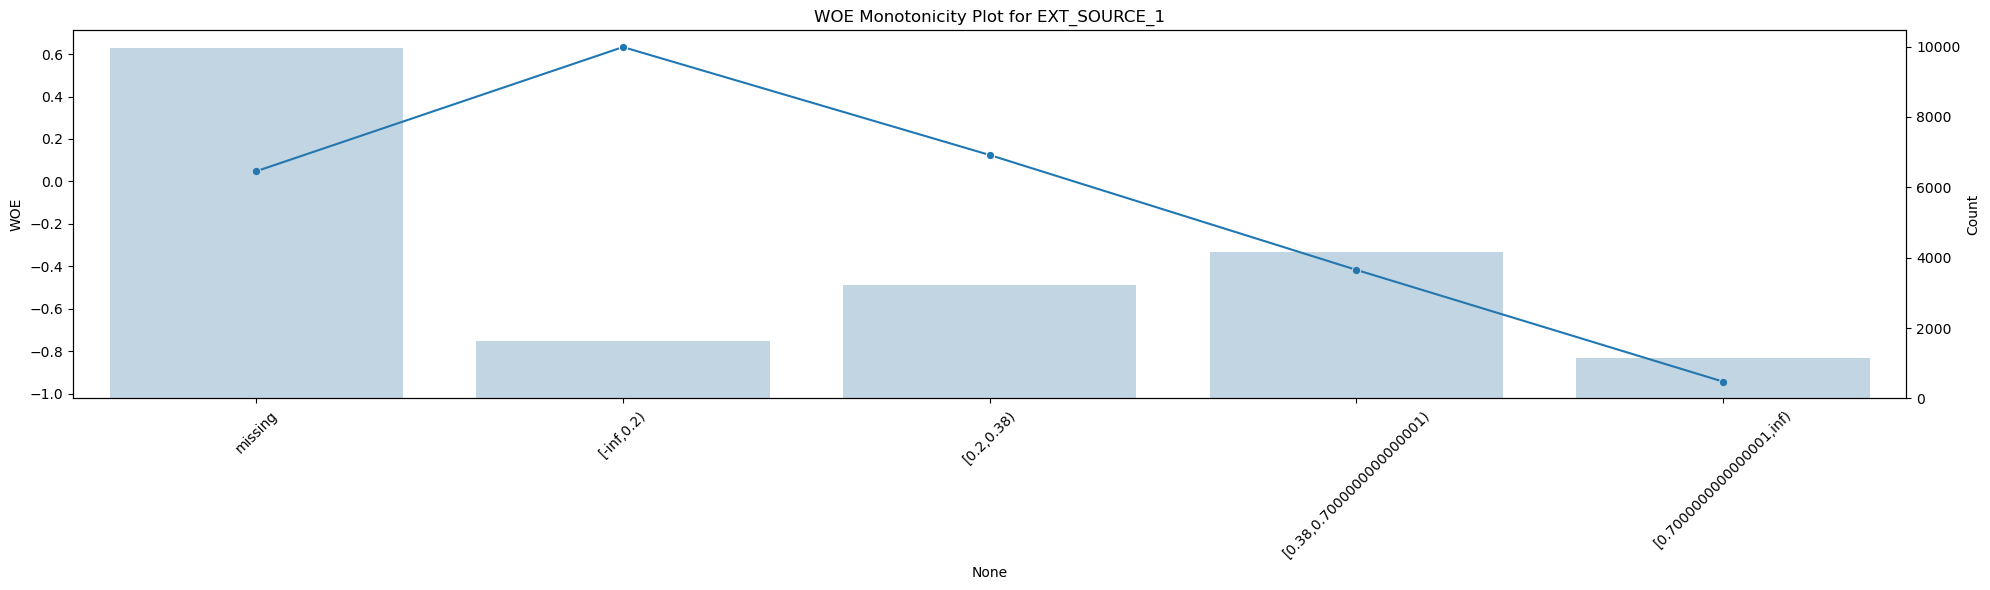

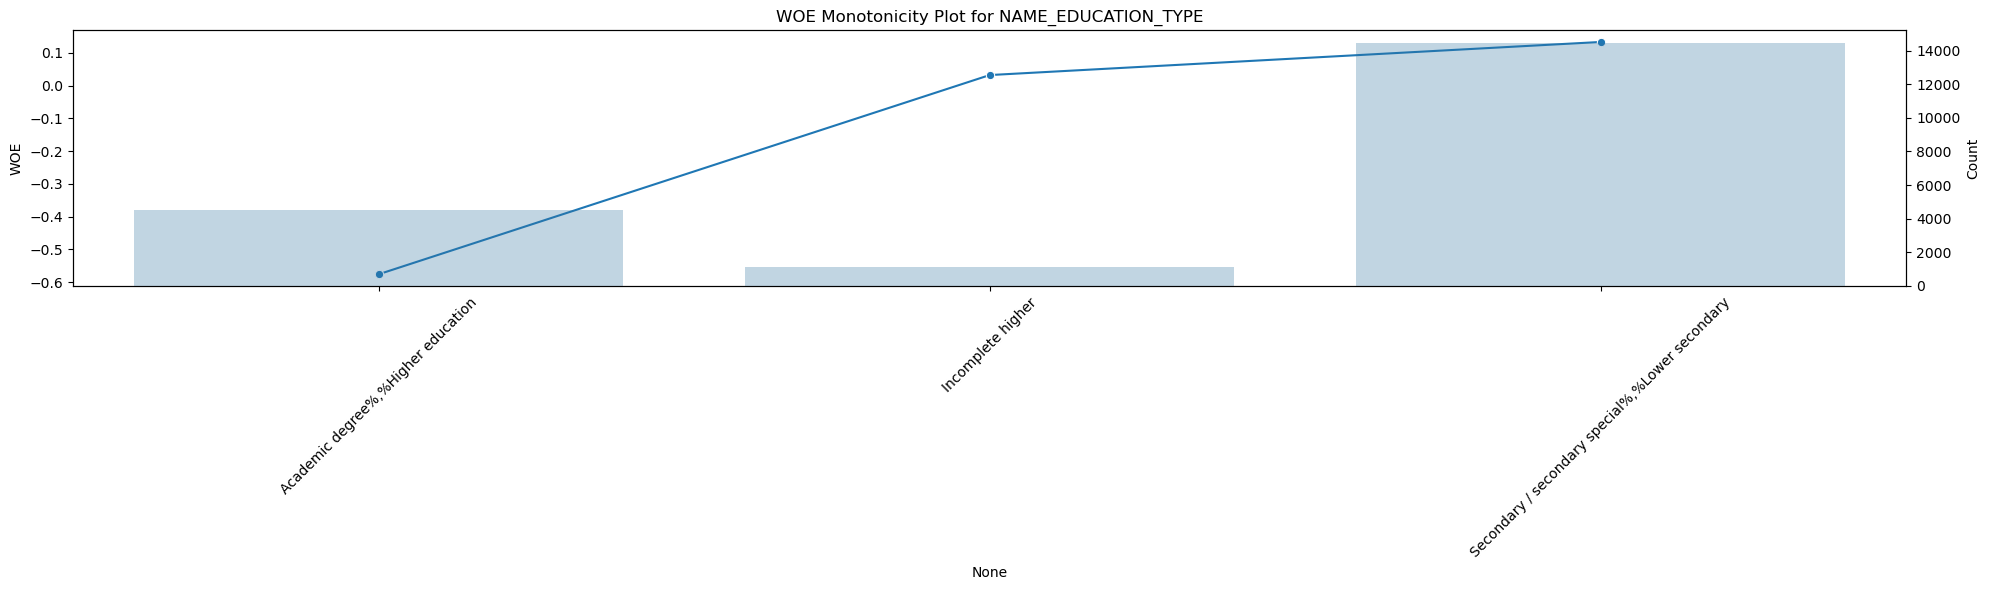

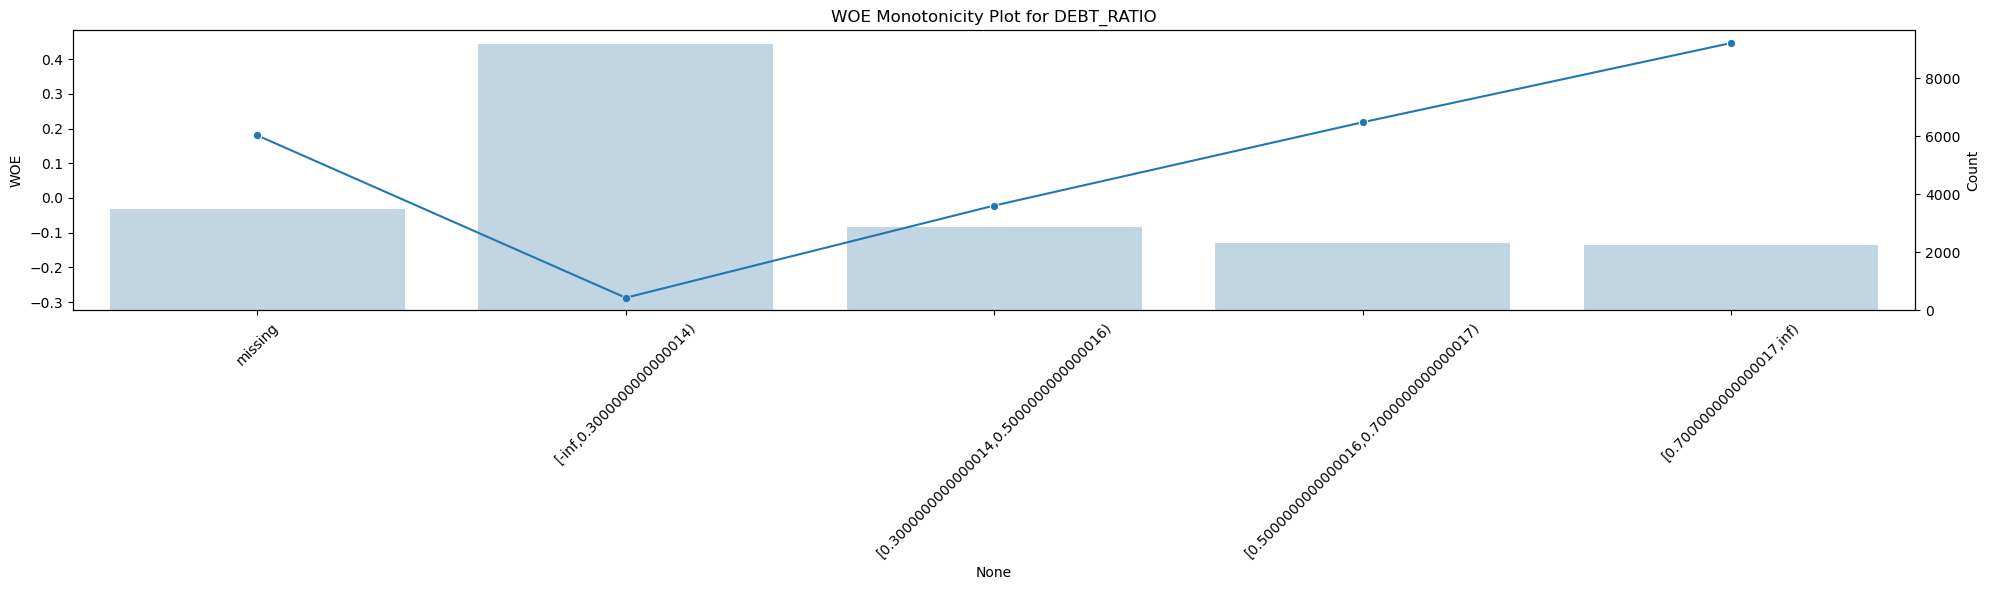

/var/folders/5_/5bgkd51n45sgbnmt71swhhsw0000gn/T/ipykernel_42609/874358824.py:41: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


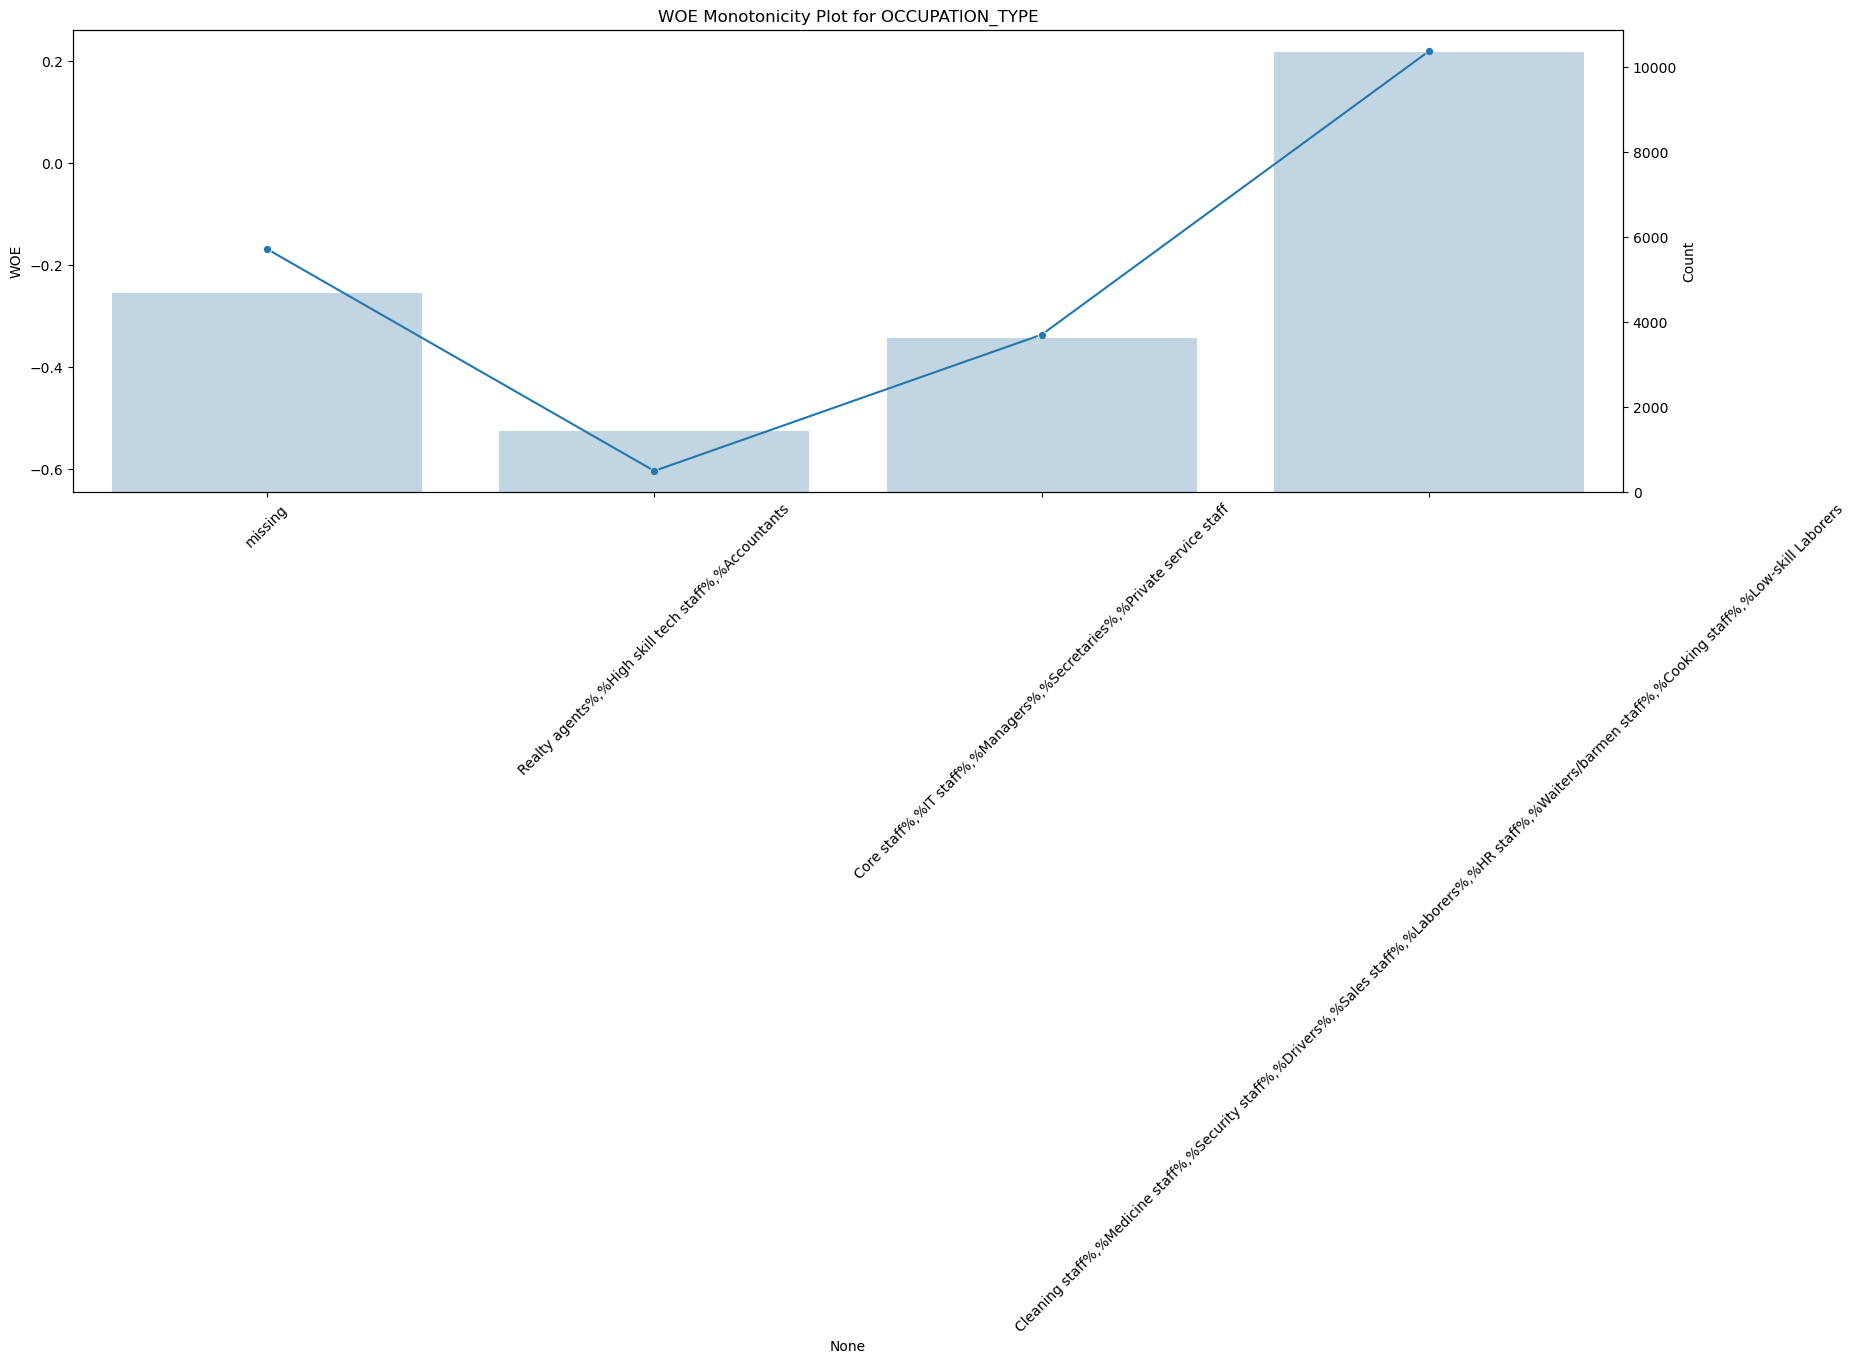

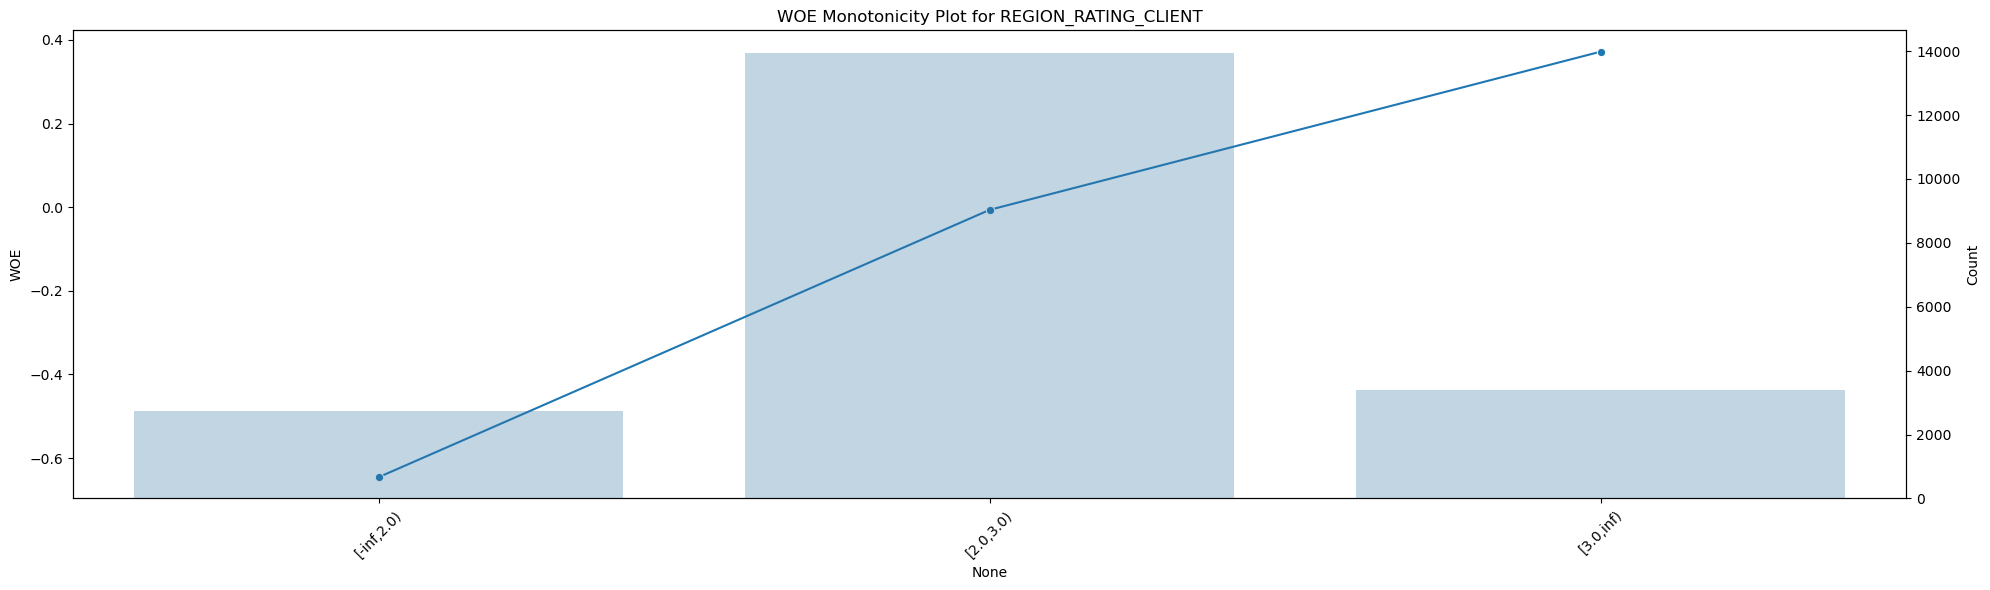

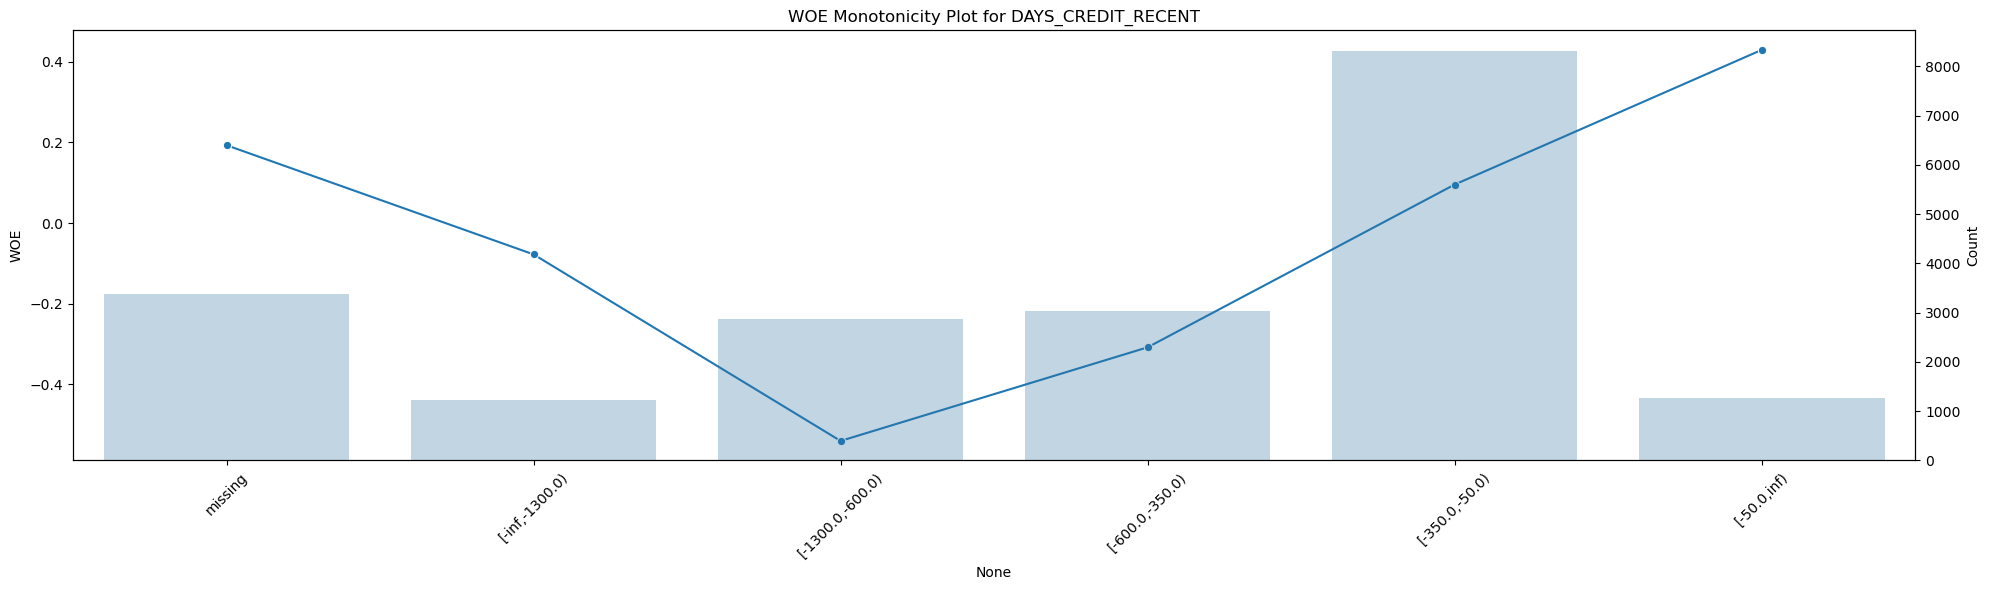

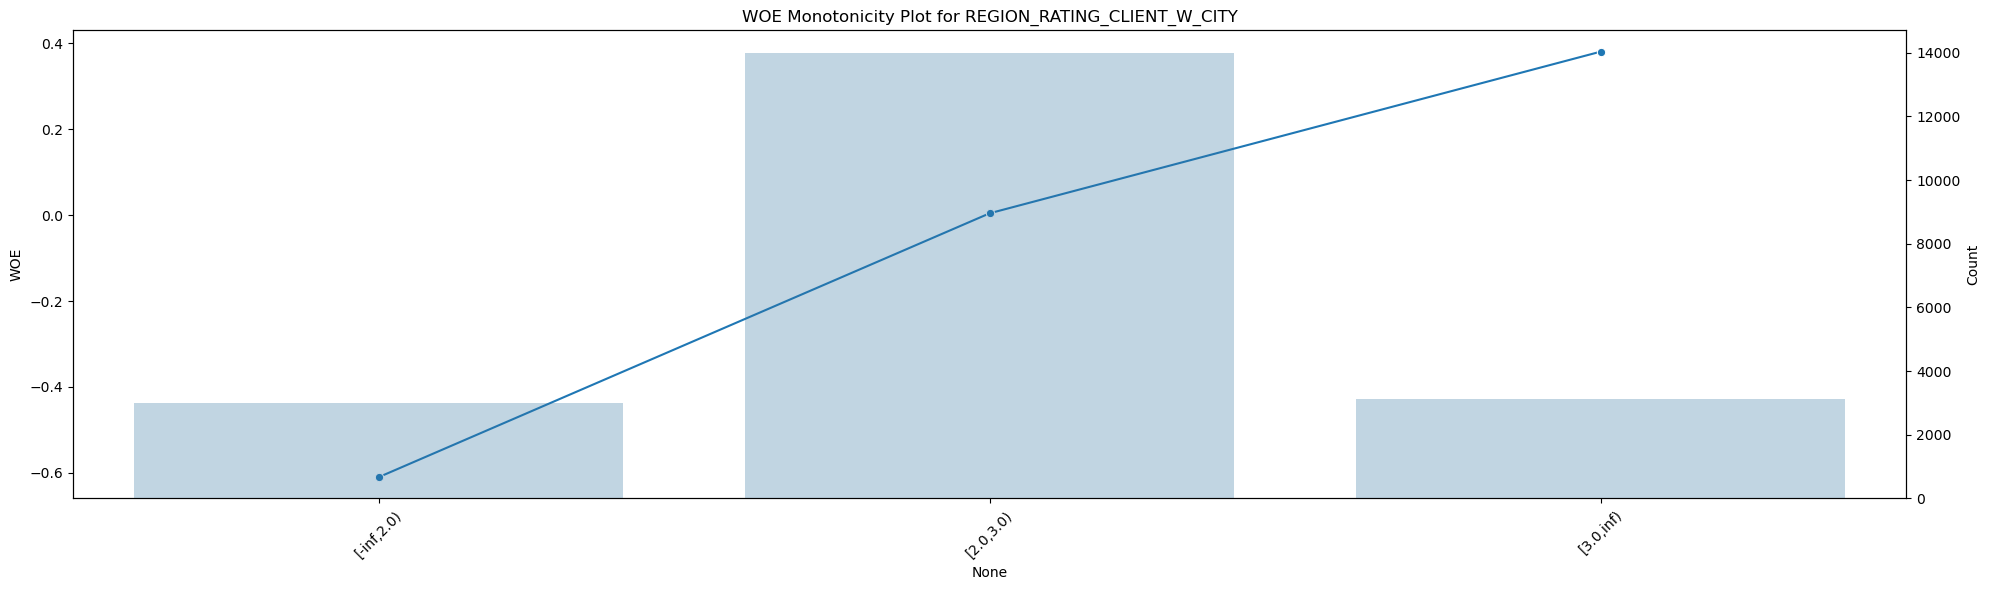

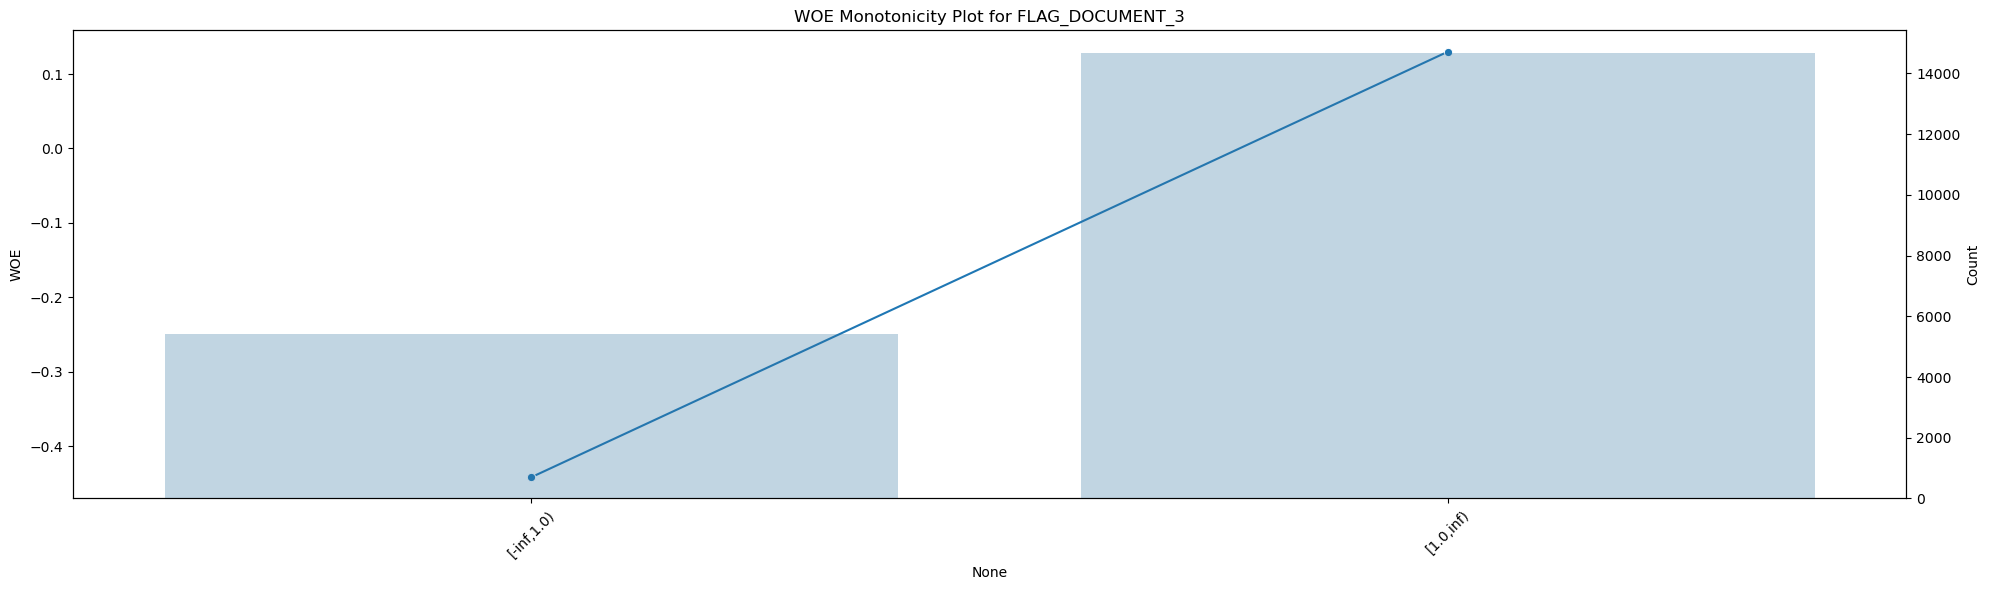

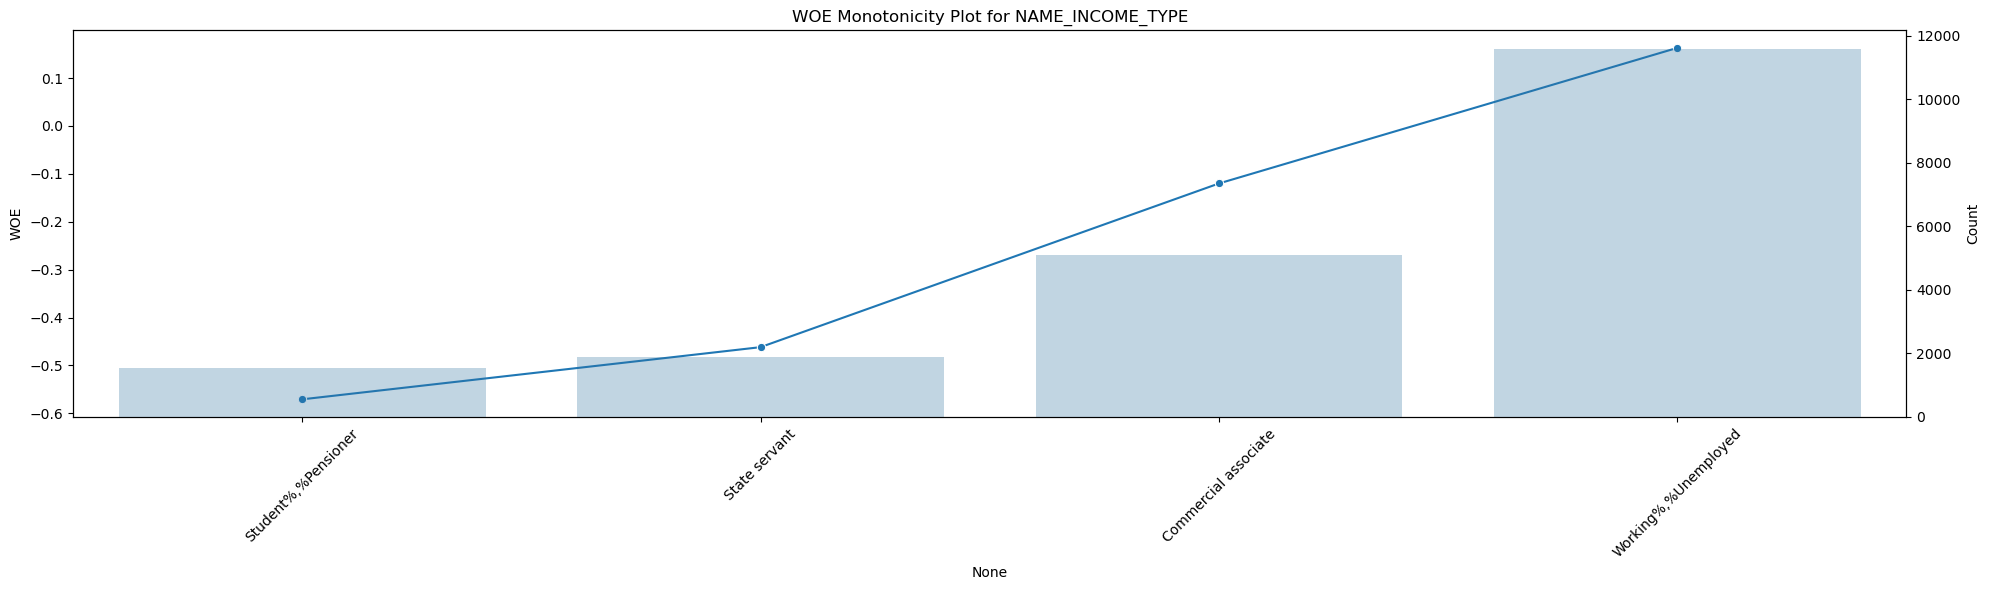

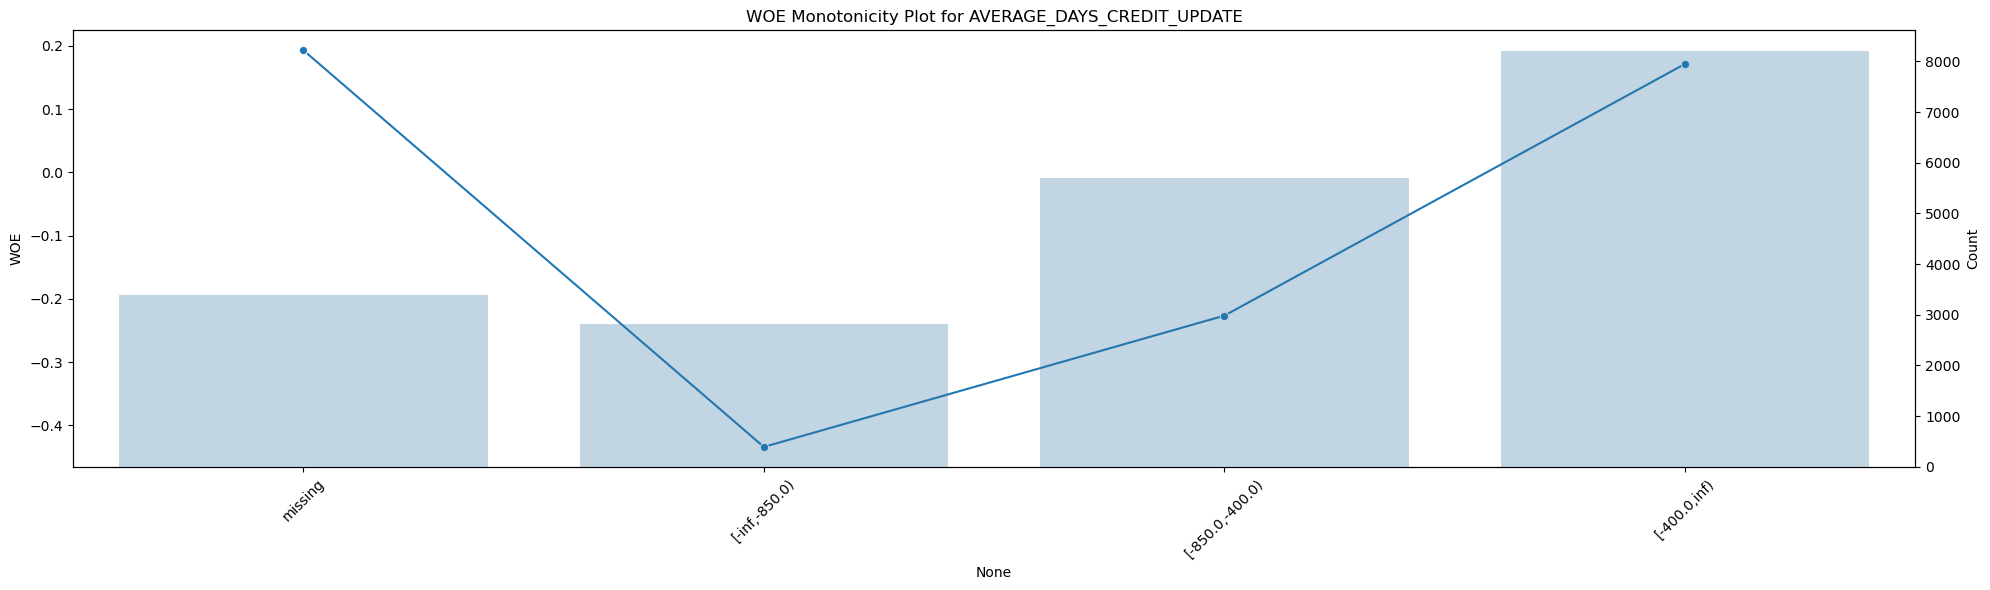

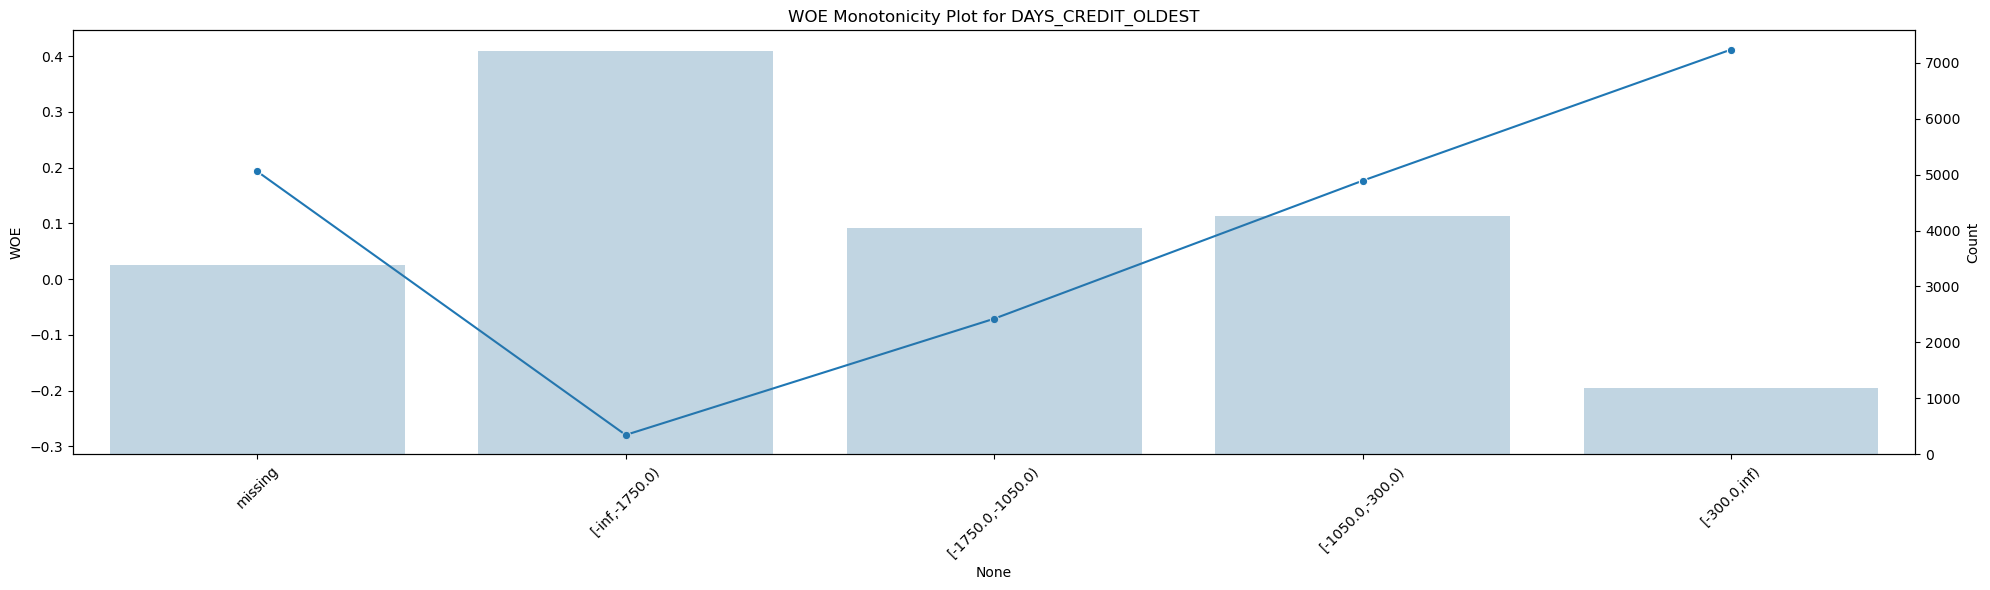

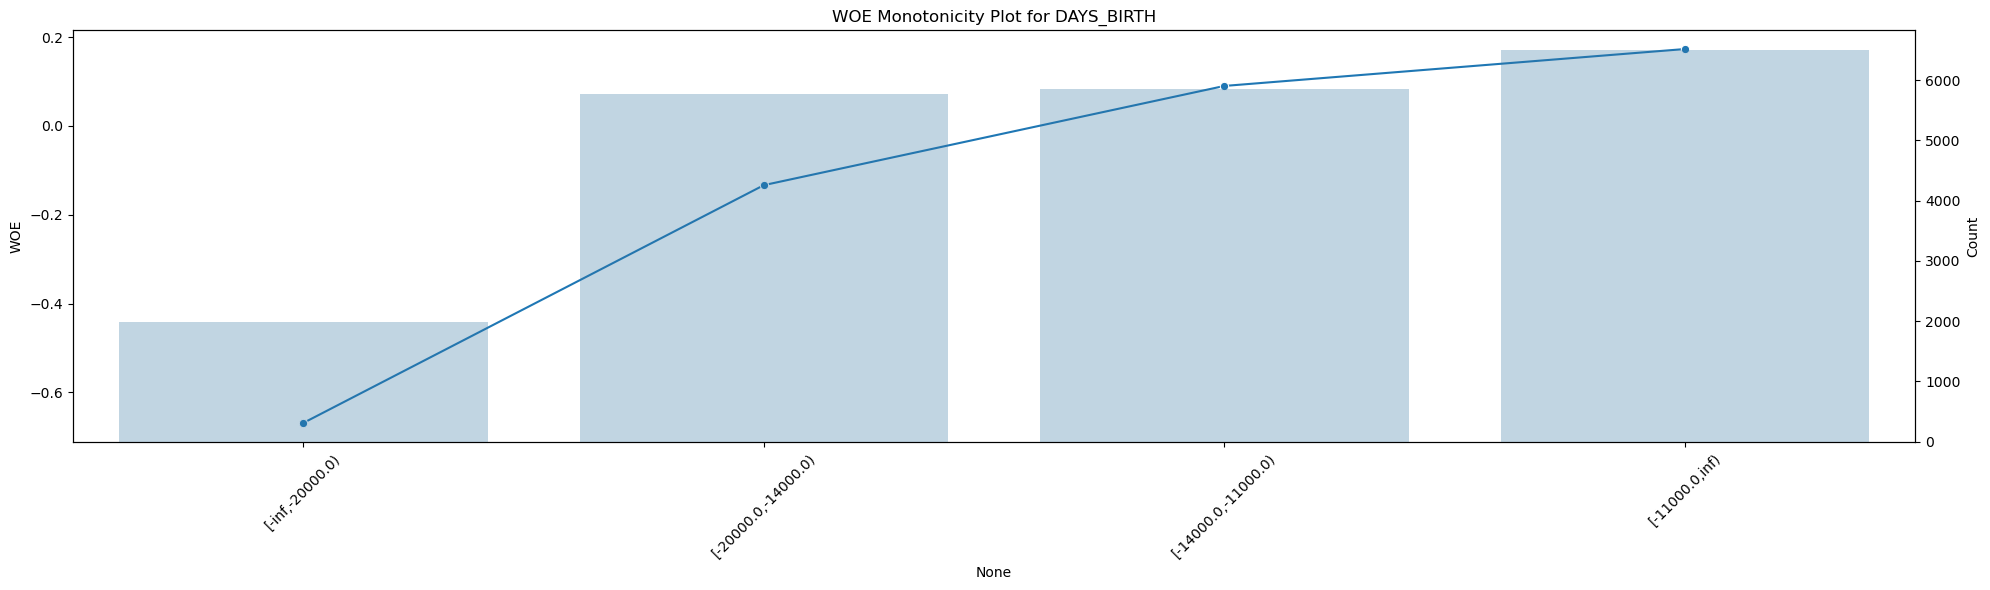

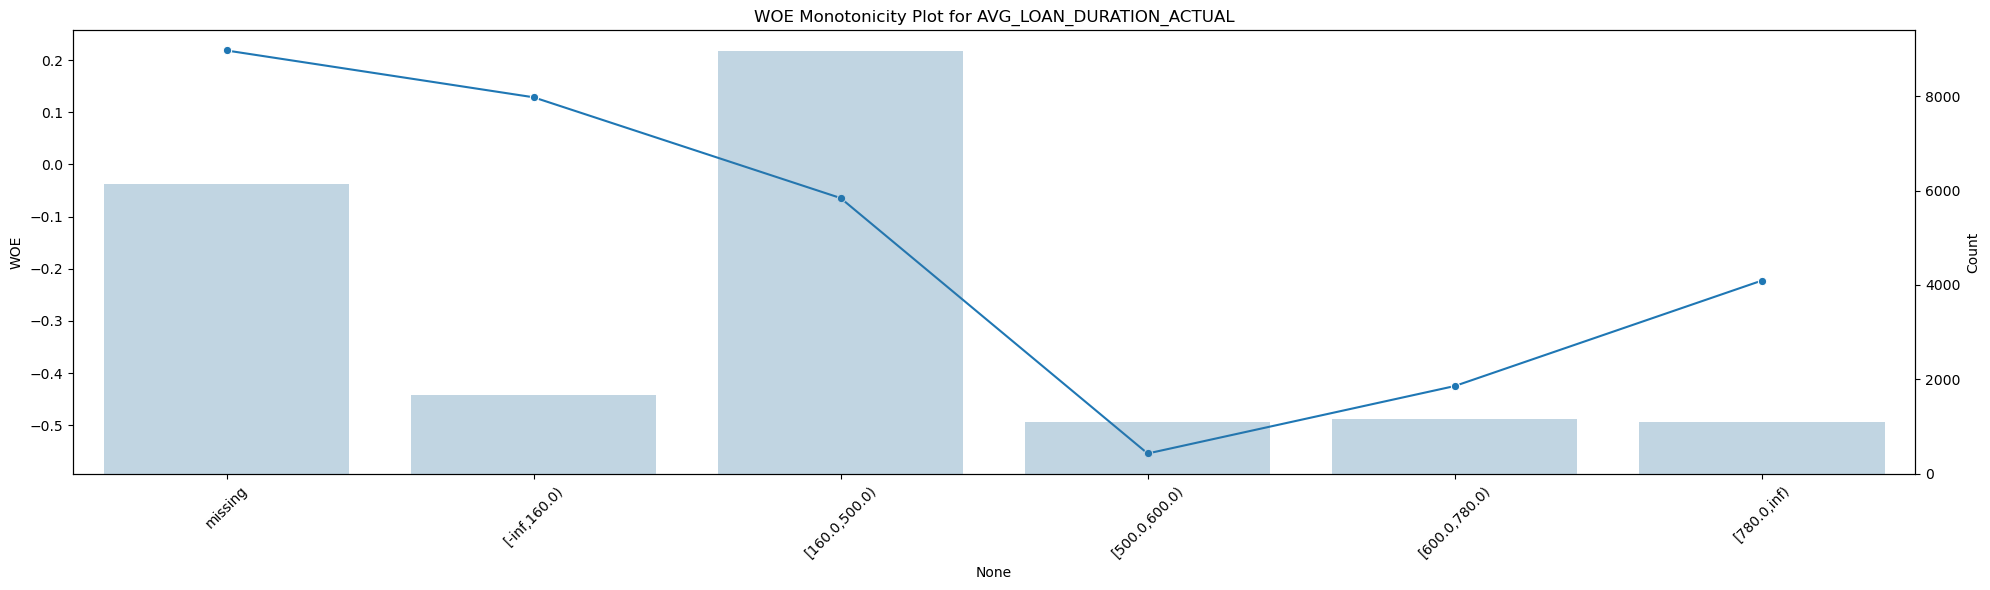

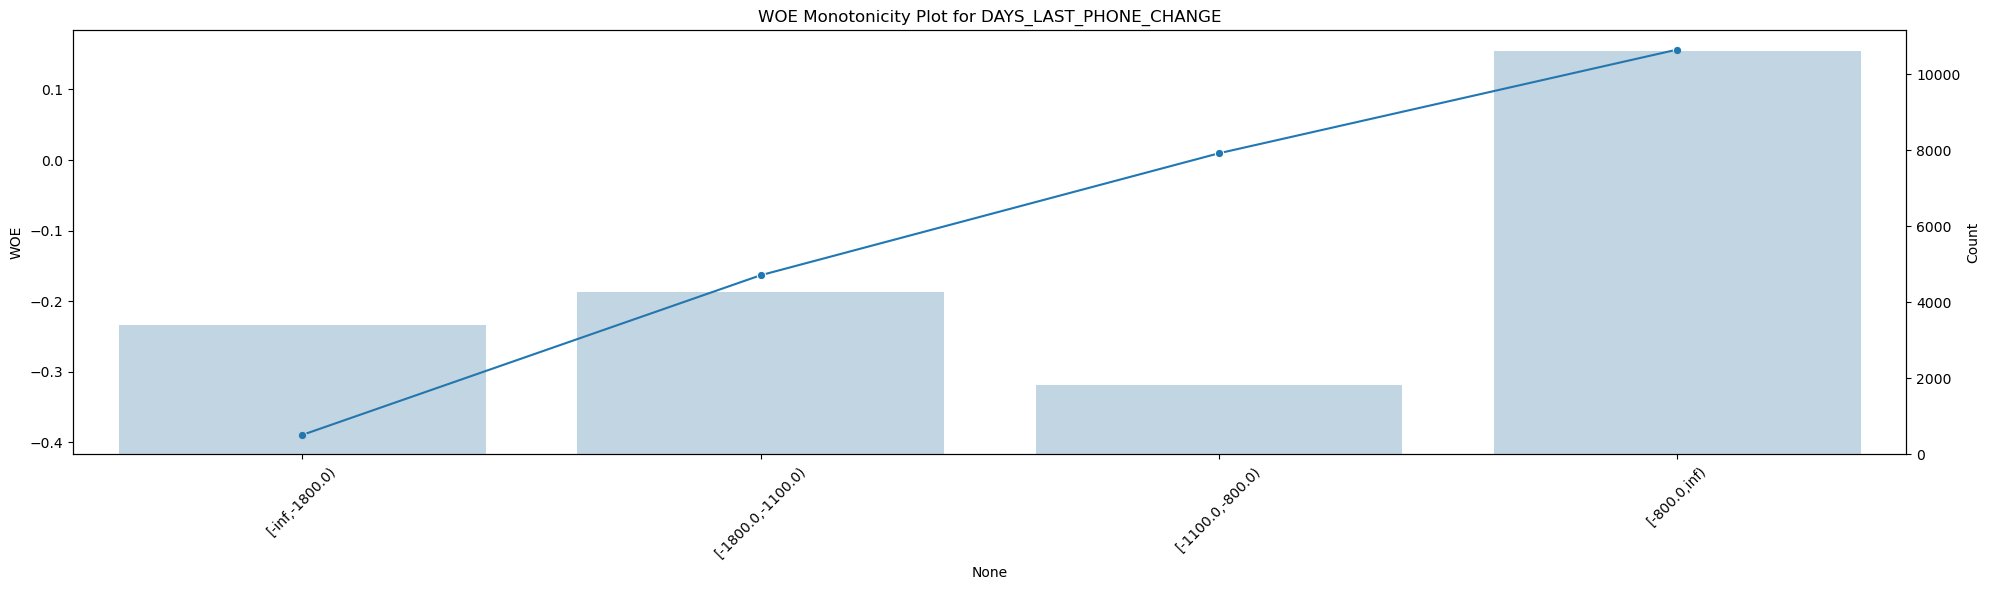

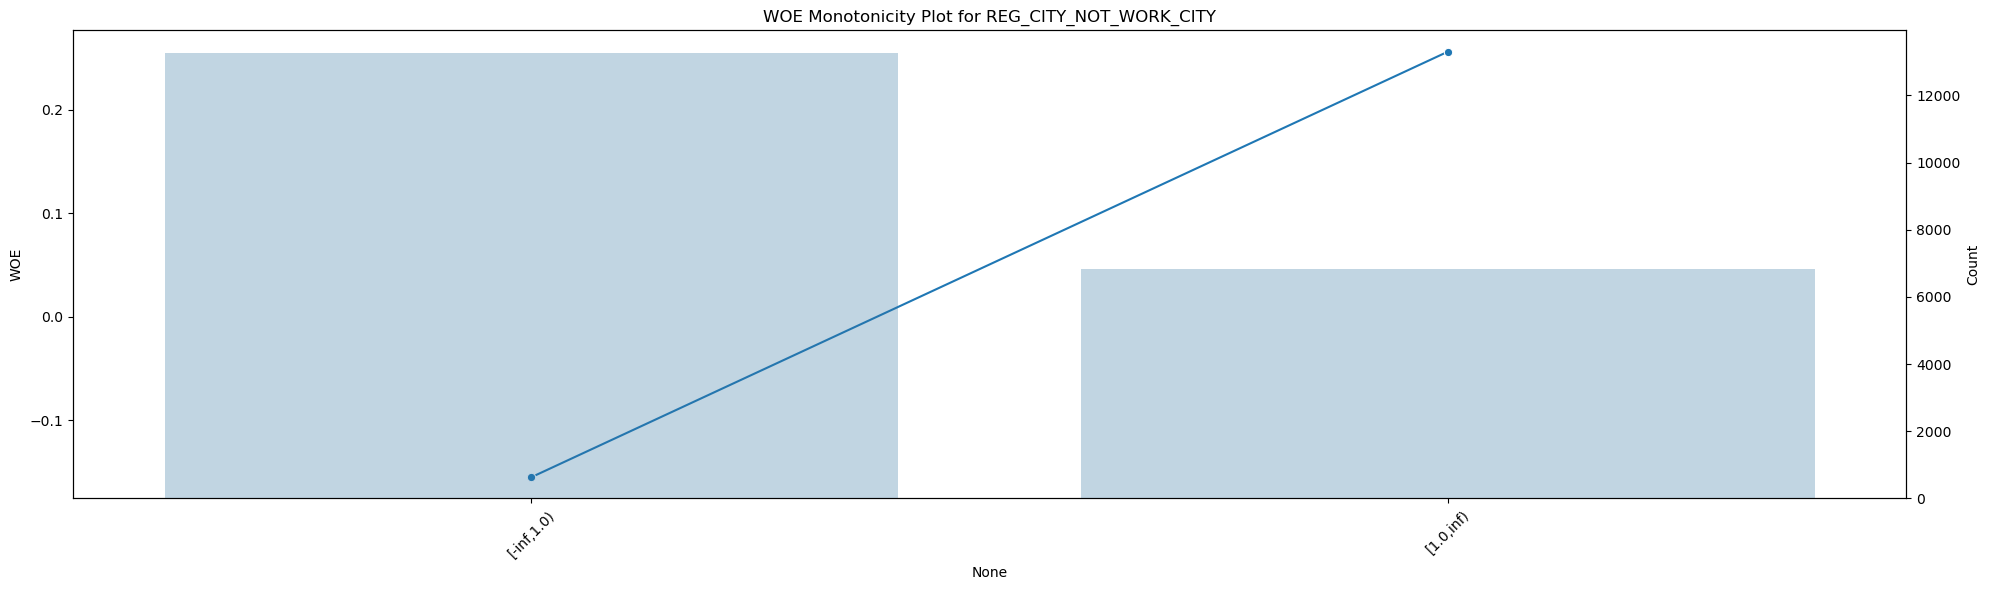

In [42]:
#CHECK FOR MONOTONICITY OF THE TOP 15 VAR/VARS INCLUDED IN THE LR MODEL
import matplotlib.pyplot as plt
import seaborn as sns

# get top 15 variables
top_15 = iv_df.head(15)['variable'].tolist()

for variable in top_15:
    
    # get bin table for each variable
    bin_df = bins[variable].copy()
    
    # create figure INSIDE loop
    fig, ax1 = plt.subplots(figsize=(20,6))

    # WOE line
    sns.lineplot(
        x=bin_df.index,
        y=bin_df['woe'],
        marker='o',
        ax=ax1
    )

    ax1.set_xticks(bin_df.index)
    ax1.set_xticklabels(bin_df['bin'], rotation=45)
    ax1.set_ylabel("WOE")

    # barplot for counts
    ax2 = ax1.twinx()

    sns.barplot(
        x=bin_df.index,
        y=bin_df['count'],
        alpha=0.3,
        ax=ax2
    )

    ax2.set_ylabel("Count")

    plt.title(f"WOE Monotonicity Plot for {variable}")
    plt.tight_layout()
    plt.show()